### IMPORT LIBRARIES
The required packages are imported into the notebook

In [3]:
# Importing the required libraries
import os
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import silhouette_score
%matplotlib inline

#### READING FILE
Reading the processed_data.xlsx file to get the filename of the images in the dataset

In [60]:
data = pd.read_excel("../processed_data.xlsx")
fullData = pd.DataFrame(data)

In [61]:
fullData.head(25)

,Patient ID,Patient Age,Patient Sex,Filename,Diagnosis,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,cataract,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,"laser spot,moderate non proliferative retinopathy",0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,normal fundus,1,0,0,0,0,0,0,0
4,4,53,Male,4_left.jpg,macular epiretinal membrane,0,0,0,0,0,0,0,1
5,5,50,Female,5_left.jpg,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0
6,6,60,Male,6_left.jpg,macular epiretinal membrane,0,0,0,0,0,0,0,1
7,7,60,Female,7_left.jpg,drusen,0,0,0,0,0,0,0,1
8,8,59,Male,8_left.jpg,normal fundus,1,0,0,0,0,0,0,0
9,9,54,Male,9_left.jpg,normal fundus,1,0,0,0,0,0,0,0


#### IMAGE PATHS

In [62]:
imageDir = "../ocular-disease-recognition-odir5k/"
trainingDir = "ODIR-5k/ODIR-5k/Training Images"
imageDirPath = os.path.join(imageDir, trainingDir)

### PROCESSING THE IMAGES 

In [63]:
imageFilePaths = [os.path.join(imageDirPath, file) for file in fullData['Filename'] if file.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Creating an empty List to hold the images
images = []

# Iterating over the images
for imageFilePath in imageFilePaths:
    image = cv2.imread(imageFilePath, cv2.IMREAD_COLOR)
  
    if image is not None: 
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (128, 128))
        image/255.0
        images.append(image)
    else:
        print(f"Failed to load {imageFilePath}")

##### RESHAPING THE IMAGES

In [64]:
# converting the images to an array
img = np.array(images)

# Reshaping the images from 3D to 2D
img = img.reshape(-1,img.shape[1]*img.shape[2]*img.shape[3])
img.shape

(7000, 49152)

In [65]:
# Set the number of clusters (k)
k = 8

# Perform k-means clustering
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels1 = kmeans.fit_predict(img)

/Users/gangas/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


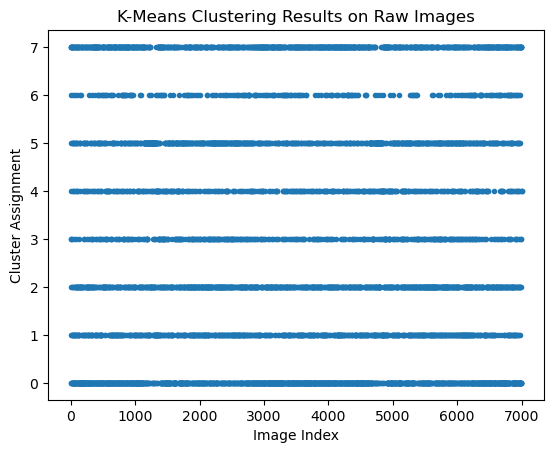

In [66]:
# Visualize the clustering results in a scatter plot 
plt.scatter(range(len(cluster_labels)), cluster_labels1, marker='.')

plt.title('K-Means Clustering Results on Raw Images')
plt.xlabel('Image Index')
plt.ylabel('Cluster Assignment')

# Show the plot
plt.show()

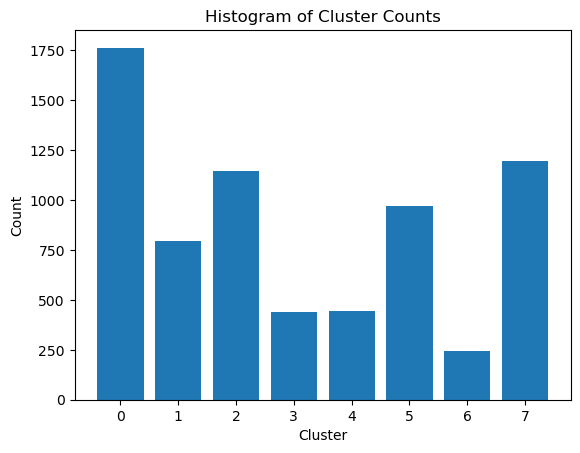

In [67]:
# Visualize the clustering results using a histogram
plt.hist(cluster_labels1, bins=range(k+1), rwidth=0.8, align='left')
plt.xticks(range(k))
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Histogram of Cluster Counts')
plt.show()

In [68]:
unique, counts = np.unique(cluster_labels1, return_counts=True)
print(unique, counts)

[0 1 2 3 4 5 6 7] [1763  797 1147  437  446  971  243 1196]


The silhouette score of the eight clusters (how well the data has been clustered by the algorithm)

In [69]:
silhouette_avg1 = silhouette_score(img, cluster_labels1)
print(f"The silhouette score for this cluster is: {silhouette_avg1}")

The silhouette score for this cluster is: 0.18391103398141986


## Using elbow method to find optimal number of clusters for the raw images
> Here we use he elbow method to determine the best and optimal number of clusters for the clustering algorithm as 8 was our initial pick simply by selcting the number of labels in our dataset.
>
> The elbow method plots the value of the cost function produced by different values of k. 
>
> The value of k that starts the linear downward trend is the optimal number of cluster

/Users/gangas/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/gangas/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/gangas/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/gangas/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change fr

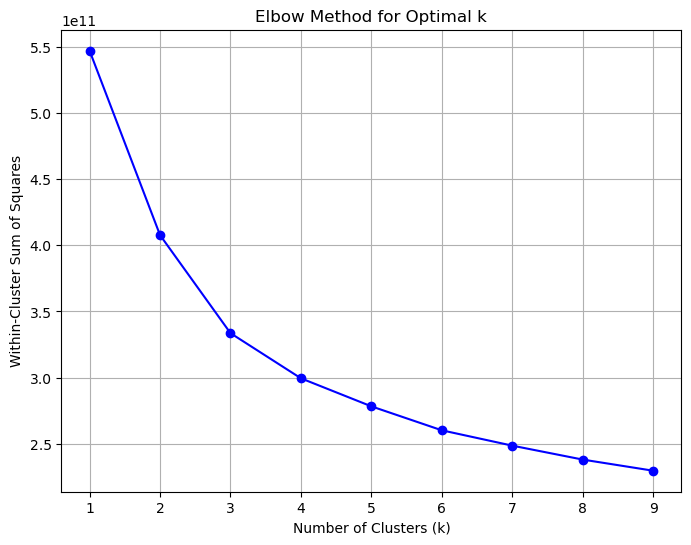

In [70]:
values = []
# Try different numbers of clusters
for k in range(1, 10):  # Try different numbers of clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(img)
    values.append(kmeans.inertia_)

# Plot the elbow graph
plt.figure(figsize=(8, 6))
plt.plot(range(1, 10), values, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares')
plt.grid(True)
plt.show()

 ### Perform clustering with optimal K

In [71]:
# from the above, we see the optimal number of clusters as 3 , where there's a steady decline 
#using the optimal number of cluster by the elbow method = 3, we perform the clustering again

k = 3

# Perform k-means clustering
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels2 = kmeans.fit_predict(img)

/Users/gangas/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


### Visualize results with optimal K

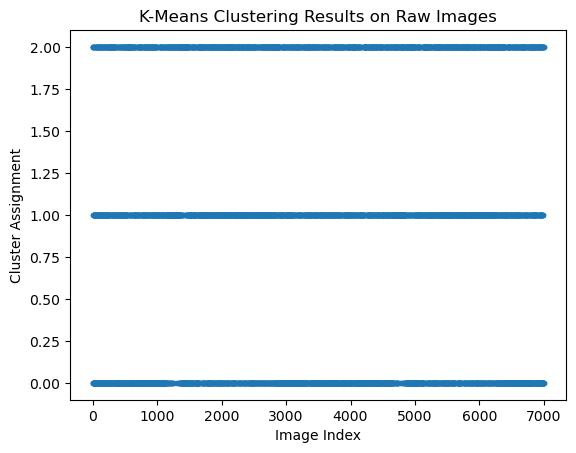

In [72]:
# Visualize the clustering results in a scatter plot 
plt.scatter(range(len(cluster_labels2)), cluster_labels2, marker='.')

plt.title('K-Means Clustering Results on Raw Images')
plt.xlabel('Image Index')
plt.ylabel('Cluster Assignment')

# Show the plot
plt.show()

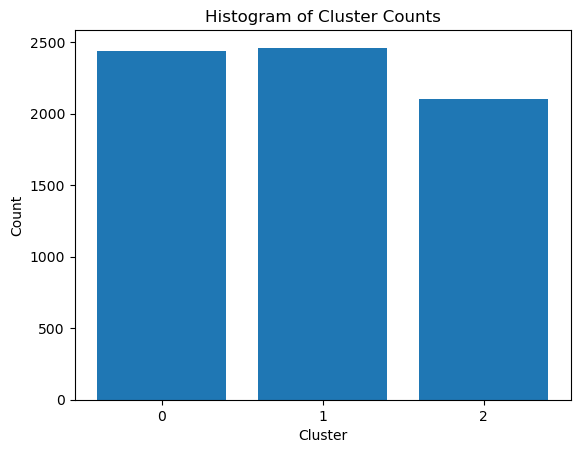

In [73]:
# Visualize the clustering results using a histogram
plt.hist(cluster_labels2, bins=range(k+1), rwidth=0.8, align='left')
plt.xticks(range(k))
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Histogram of Cluster Counts')
plt.show()

In [74]:
unique, counts = np.unique(cluster_labels2, return_counts=True)
print(unique, counts)

[0 1 2] [2439 2461 2100]


- The silhouette score of the three clusters (how well the data has been clustered by the algorithm) 

In [75]:
silhouette_avg2 = silhouette_score(img, cluster_labels2)
print(f"The silhouette score for this cluster is: {silhouette_avg2}")

The silhouette score for this cluster is: 0.2234732653866201


## APPLYING ICA
> we intend to analyze the clustering without dimensionality reduction (DRA) as shown above against dimensionality reduced images . so in this section, we apply ICA to the images and then perfom the k means once again, to analyze and understand if DRA would play a signifanct part in better clustering.

> We often extract new features from original features for the purpose of reducing the dimensions of feature space and achieving better performances.
>
> By using Independent Component Analysis (ICA) on the images, it confidently produces new features that are independent from each other.
>
> It effectively reduces the feature space while maintaining the classification effectiveness. 

In [76]:
numberOfComponent = 3
ica = FastICA(n_components=numberOfComponent, random_state=20)
ica.fit(img)
icaImage = ica.transform(img)

## CLUSTERING
> After using the Independent Components Analysis to extract the features and using the elbow method to determine the optimal number of clusters for the clustering
>
> We are going to use the k-means clustering to cluster the newly extracted images and see if we can create different cluster of the images.
>
> We will be using the random number of cluster as 8 because we have 8 different labels. 
>
> Also we will be using the Elbow method to determine the optimal number of clusters for our images.   


In [77]:
# Choosing the random number of cluster as 8
kmeans = KMeans(n_clusters=8, random_state=42)
# Fit the KMeans model to the transformed ICA images
kmeans.fit(icaImage)
kMeansResult1 = kmeans.predict(icaImage)

/Users/gangas/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


#### PLOTTING

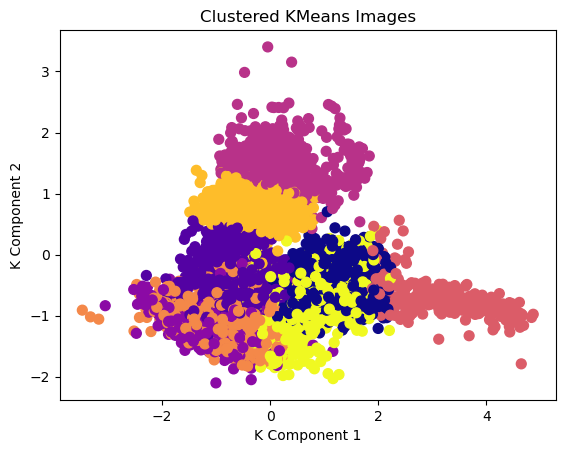

In [78]:
plt.scatter(icaImage[:, 0], icaImage[:, 1], c=kMeansResult1, cmap='plasma', s=50)

# Add a title and axis labels
plt.title('Clustered KMeans Images')
plt.xlabel('K Component 1')
plt.ylabel('K Component 2')

# Show the plot
plt.show()

<BarContainer object of 8 artists>

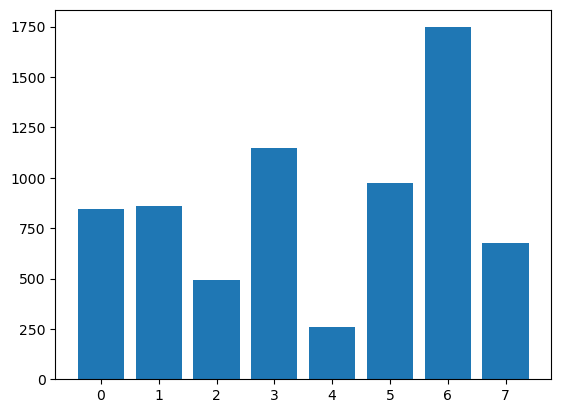

In [79]:
unique, counts = np.unique(kMeansResult1, return_counts=True)
plt.bar(unique,counts)

In [80]:
print(unique, counts)

[0 1 2 3 4 5 6 7] [ 844  862  491 1149  258  972 1747  677]


In [81]:
silhouette_avg3 = silhouette_score(img,kMeansResult1 )
print(f"The silhouette score for this cluster is: {silhouette_avg3}")

The silhouette score for this cluster is: 0.16049621464400948


## ELBOW METHOD
> Using the elbow method to determine the best and optimal number of clusters for the clustering algorithm.
>
> The elbow method plots the value of the cost function produced by different values of k. 
>
> The value of k that start the linear downward trend is the optimal number of cluster
>
> It was discovered that 4 was the optimal number for the cluster.

/Users/gangas/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/gangas/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/gangas/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/gangas/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change fr

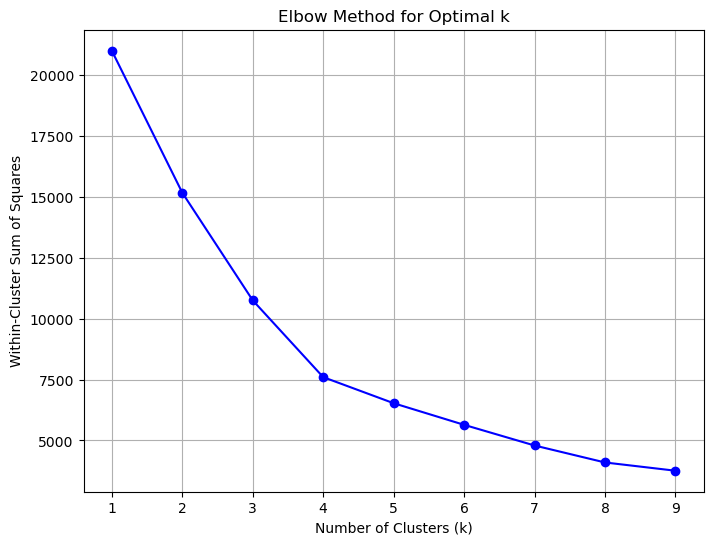

In [82]:
values = []
# Try different numbers of clusters
for k in range(1, 10):  # Try different numbers of clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(icaImage)
    values.append(kmeans.inertia_)

# Plot the elbow graph
plt.figure(figsize=(8, 6))
plt.plot(range(1, 10), values, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares')
plt.grid(True)
plt.show()

In [83]:
# using the optimal number of cluster by the elbow method = 4
kmeans = KMeans(n_clusters=4, random_state=42)
# Fit the KMeans model to the transformed ICA images
kmeans.fit(icaImage)
kMeansResult = kmeans.predict(icaImage)

/Users/gangas/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


***Plotting the clustered image***

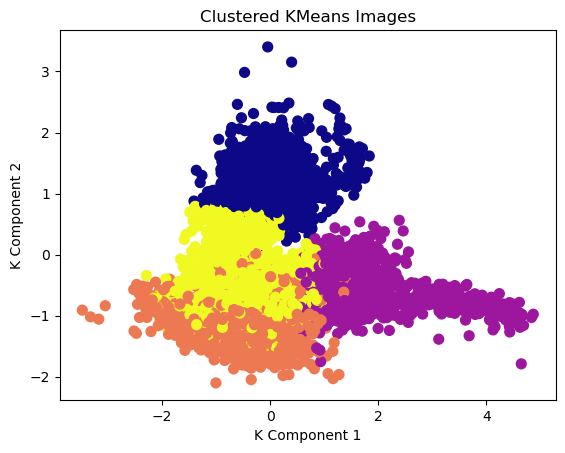

In [84]:
# Visualize the clustering results in a scatter plot 
plt.scatter(icaImage[:, 0], icaImage[:, 1], c=kMeansResult, cmap='plasma', s=50)

# Add a title and axis labels
plt.title('Clustered KMeans Images')
plt.xlabel('K Component 1')
plt.ylabel('K Component 2')

# Show the plot
plt.show()

<BarContainer object of 4 artists>

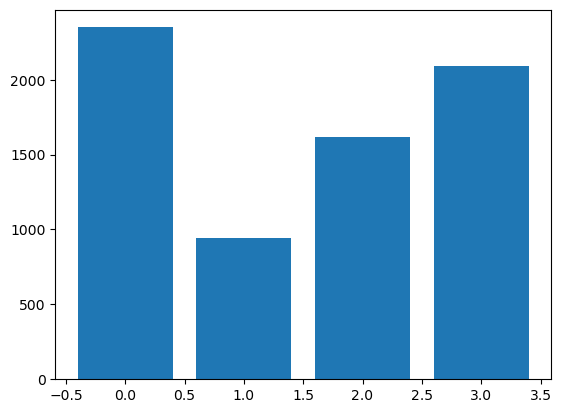

In [85]:
unique, counts = np.unique(kMeansResult, return_counts=True)
plt.bar(unique,counts)

In [86]:
print(unique, counts)

[0 1 2 3] [2350  942 1615 2093]


In [ ]:
- The silhoutte score 

In [88]:
silhouette_avg3 = silhouette_score(icaImage, kMeansResult)
print(f"The average silhouette score is: {silhouette_avg3}")

The average silhouette score is: 0.38465492819811786


#### THIS IS AN ANALYSIS OF THE RESULTS OF THE CLUSTERING BETWEEN K-MEANS WITH DIMENSONALITY REDUCTION ALGORITHM AND ONE WITHOUT DIMENSIONALITY REDUCTION ALGORITHM.

 #### Comparison of the histogram of " 8 clusters" between raw images and that of dimensionality reduced images
> The histogram of raw images shows a fairly even distribution among the clusters, with most clusters containing a similar number of images suggesting that the K-means algorithm on the raw images is dividing the images fairly evenly probably becuase of difficulty in noticing the more detailed and nuanced structure within the image dataset.

> While the histogram of dimensionality reduced images shows a more varied distribution of clusters, with some clusters containing many more images than others.

>This suggests that after the dimensionality-reduction , some clusters are more densely populated,  showing they share more features in common or the features are more observable leading to the distributions.

#### Comparison of the histogram "distribution after elbow method" between raw images and that of dimensionality reduced images
> firstly There are more (4) cluster groups in the histogram of the dimensionality reduced images because the use of reduction algorithm beforehand affects the optimal n0_of clusters suggested by the Elbow Method.

>Secondly The number of clusters is different for the raw and dimensionality-reduced images, suggesting that dimensionality reduction can reveals additional structure or patterns in the data that are not as evident in the raw, high-dimensional form.


In summary, the histograms suggest that the dimensionality reduction process may be revealing more meaningful patterns in the data that aren't visible in the original, more complex dataset